In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [6]:
import sys

sys.path.append('../../scripts')

In [7]:
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
import decoupler as dc
import scipy.sparse as sp
import pandas as pd

from train_loo import preprocess_crc

In [8]:
adata = sc.read_h5ad("/data2/a330d/datasets/crc/raw_zenodo/crc_210.h5ad")
adata = preprocess_crc(adata, n_top_genes=2000, n_neighbors=200, labels_key='coarse_type', domains_key='typ_clean')

/data/a330d/projects/cellina-reproducibility/notebooks/loo_benchmarks/../../scripts/train_loo.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


In [13]:
mask_crc_epi = (
    (adata.obs["coarse_type"] == "Epithelial") &
    (adata.obs["typ_clean"] == "CRC")
)

# Create a copy for visualization
adata.obs["mask1"] = np.where(mask_crc_epi, "removed", "kept")

/tmp/ipykernel_2795008/1514530614.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'mask1' as categorical


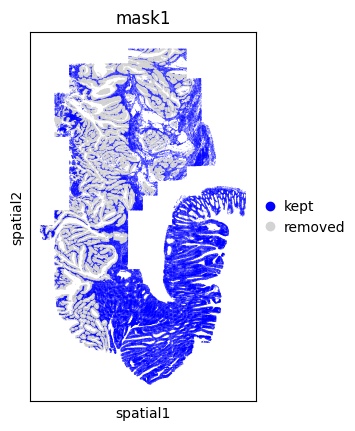

In [14]:
sc.pl.spatial(
    adata,
    color="mask1",
    palette={"removed": "lightgrey", "kept": "blue"},
    spot_size=100,
)

In [15]:
A = adata.obsp["spatial_connectivities"]  # sparse matrix
mask_crc_epi = mask_crc_epi.values  # convert to numpy

# Multiply adjacency with mask to find neighbors
neighbor_mask = A.dot(mask_crc_epi.astype(int)) > 0

In [16]:
mask_total = mask_crc_epi | neighbor_mask

/tmp/ipykernel_2795008/2645077661.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'mask2' as categorical


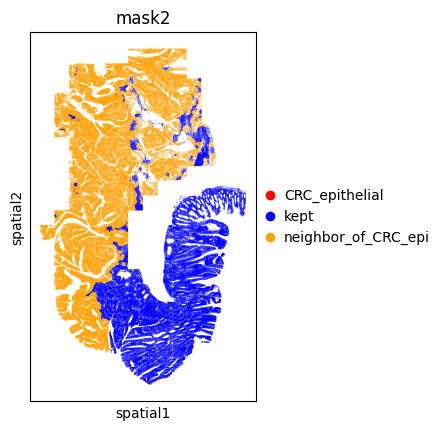

In [17]:
adata.obs["mask2"] = "kept"
adata.obs.loc[mask_crc_epi, "mask2"] = "CRC_epithelial"
adata.obs.loc[neighbor_mask, "mask2"] = "neighbor_of_CRC_epi"

sc.pl.spatial(
    adata,
    color="mask2",
    palette={
        "kept": "blue",
        "CRC_epithelial": "red",
        "neighbor_of_CRC_epi": "orange"
    },
    spot_size=100,
)

# Quantitative

In [36]:
is_crc = adata.obs["typ_clean"] == "CRC"
is_celltype = "Epithelial"

mask_crc_epi = (
    (adata.obs["coarse_type"] == is_celltype) &
    (adata.obs["typ_clean"] == "CRC")
)

A = adata.obsp["spatial_connectivities"]

# optional: remove self-loops
A = A.copy()
A.setdiag(0)

neighbor_mask = A.dot(mask_crc_epi.astype(int).values) > 0

mask_total = mask_crc_epi.values | neighbor_mask

In [37]:
crc_remaining_after_epi = np.sum(is_crc & ~mask_crc_epi)

crc_original = np.sum(is_crc)
crc_removed_epi = np.sum(is_crc & mask_crc_epi)

In [38]:
crc_remaining_after_total = np.sum(is_crc.values & ~mask_total)

crc_removed_total = np.sum(is_crc.values & mask_total)

In [35]:
frac_remaining_epi = crc_remaining_after_epi / crc_original
frac_remaining_total = crc_remaining_after_total / crc_original

print(f"Fraction remaining (no {is_celltype}): {frac_remaining_epi:.3f}")
print(f"Fraction remaining (no {is_celltype} + neighbors): {frac_remaining_total:.3f}")

Fraction remaining (no Endothelial): 0.970
Fraction remaining (no Endothelial + neighbors): 0.212


In [39]:
frac_remaining_epi = crc_remaining_after_epi / crc_original
frac_remaining_total = crc_remaining_after_total / crc_original

print(f"Fraction remaining (no {is_celltype}): {frac_remaining_epi:.3f}")
print(f"Fraction remaining (no {is_celltype} + neighbors): {frac_remaining_total:.3f}")

Fraction remaining (no Epithelial): 0.379
Fraction remaining (no Epithelial + neighbors): 0.071
